In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [73]:
x = np.array([8,8,8,8,8,8,8,19,8,8,8])
y = np.array([6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89])
y_err = np.array([1.24] * len(y))

In [74]:
# For set 4 (duplicate)
def replace_duplicates_with_mean(x, y):
    y_new = []
    y_err_new = []
    vals, counts = np.unique(x, return_counts=True)
    for val in vals:
        m = np.mean([y[i] for i in range(len(y)) if x[i] == val])
        y_new.append(m)
    y_err_new = 1.24/np.sqrt(counts)
    return vals, np.array(y_new), np.array(y_err_new)

x, y, y_err = replace_duplicates_with_mean(x, y)

<ErrorbarContainer object of 3 artists>

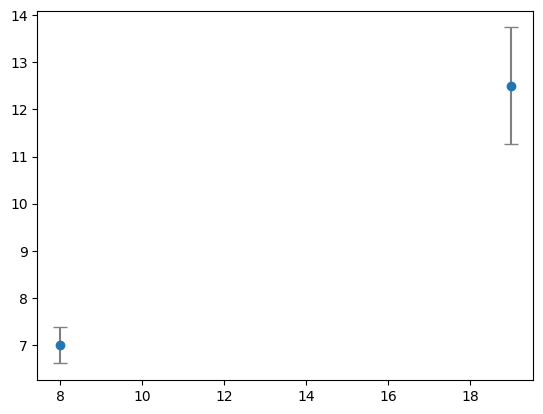

In [75]:
plt.errorbar(x, y, yerr=y_err, fmt='o', ecolor='gray', capsize=5)

In [41]:
import scipy.optimize as opt

def delete_zeros(bins,counts,err):
    '''
    Inputs:
    bins = the frequency bin centers
    counts = the frequency data
    err = the error data
    Output:
    new_bins = bin centers, but if the frequency of a bin center is zero the bin is removed
    new_counts = frequency data, but if "                    "
    new_err = error data, but if "                       "
    '''
    zeros = np.where(counts==0) # Find the indices where the frequency data is zero
    mask = np.ones(len(counts),dtype=bool) # create a mask of True values
    mask[zeros[0]] = False # Turn the zero parts of the mask False
    new_counts = counts[mask] # Recreate the bin data without the False parts
    new_bins = bins[mask] # Recreate the frequency data without the False parts
    new_err = err[mask] # Recrete the "      "
    return new_bins, new_counts, new_err

def linear_func(x, a, b):
    return a * x + b

In [76]:
popt, pcov = opt.curve_fit(f=linear_func, xdata=x, ydata=y, sigma=y_err, absolute_sigma=True) # Fit function
uncert = np.sqrt(np.diag(pcov)) # Extract uncertainty from fit

In [77]:
print(popt)
print(uncert)

[0.49990909 3.00172727]
[0.11822936 1.12783626]


In [78]:
def chisq(func,popt,x,y,sig):
    '''
    Inputs:
    func = function to generate expected value
    x = x data
    y = y data
    sig = sigma data
    Outputs:
    chi2 = chi-squared value
    '''
    expected_vals = func(x, *popt) # Again, better off using *popt
    return np.sum((y-expected_vals)**2/sig**2)

chi2 = chisq(linear_func,popt,x,y,y_err)
chi2

5.130468946546644e-30

In [79]:
dof = len(x) - 2 # Our degrees of freedom is equal to the number of data points minus the number of fit parameters

dof

0

In [80]:
chi2/dof

/var/folders/wy/zv30vjj534ldq0pwslz20nkr0000gn/T/ipykernel_91833/1020507143.py:1: RuntimeWarning: divide by zero encountered in scalar divide
  chi2/dof


inf

In [81]:
from scipy import stats

chi2_probs = 1 - stats.chi2.cdf(chi2,dof) # Get the probability by subtracting 1 from the cumulative distribution function

chi2_probs

nan

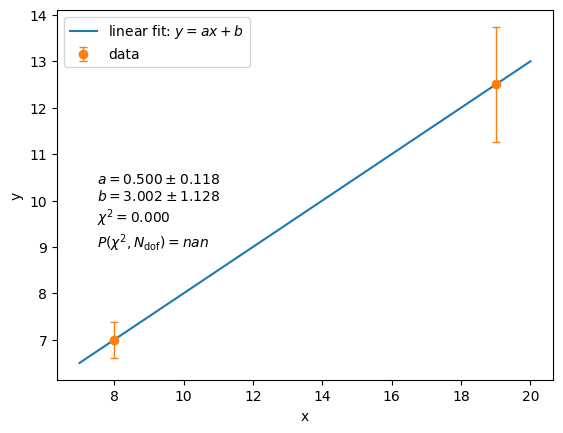

In [84]:
pad = 1
x_con = np.linspace(start=min(x)-pad, stop=max(x)+pad, num=100, endpoint=True) # Define x for smoother plotting of our poisson fit function

plt.plot(x_con, linear_func(x_con, *popt), label="linear fit: $y=ax+b$") # Plot fit function
plt.errorbar(x, y, yerr=y_err, linewidth=1, ls='none', fmt='o', capsize=3, label = "data") # Plot actual data
plt.text(7.5, 9, f"$a = {popt[0]:.3f}\pm{uncert[0]:.3f}$ \n$b = {popt[1]:.3f}\pm{uncert[1]:.3f}$ \n$\chi^2 = {chi2:.3f}$ \n$P(\chi^2, N_\\text{{dof}}) = {chi2_probs:.3f}$", fontsize=10)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()